### Implement the Baseline Model - Logistic Regression

### 1. Import the python libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline 
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import joblib

### 2. Import the data 

In [2]:
train_filepath = '../data/processed/neiss_feature-engineered_train_data.parquet'
eval_filepath = '../data/processed/neiss_feature-engineered_eval_data.parquet'
holdout_filepath =  '../data/processed/neiss_feature-engineered_holdout_data.parquet'

In [3]:
train_data= pd.read_parquet(train_filepath)
eval_data = pd.read_parquet(eval_filepath)
holdout_data = pd.read_parquet(holdout_filepath)

In [9]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 100 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   cat__Diagnosis_41                        float64
 1   cat__Diagnosis_42                        float64
 2   cat__Diagnosis_46                        float64
 3   cat__Diagnosis_47                        float64
 4   cat__Diagnosis_48                        float64
 5   cat__Diagnosis_49                        float64
 6   cat__Diagnosis_50                        float64
 7   cat__Diagnosis_51                        float64
 8   cat__Diagnosis_52                        float64
 9   cat__Diagnosis_53                        float64
 10  cat__Diagnosis_54                        float64
 11  cat__Diagnosis_55                        float64
 12  cat__Diagnosis_56                        float64
 13  cat__Diagnosis_57                        float64
 14  cat__Diagnosis_58          

### 3. Setup the train/evaluation dataset

In [4]:
X_train = train_data.drop(columns=['Hospitalized'])
y_train = train_data['Hospitalized']
X_eval = eval_data.drop(columns=['Hospitalized'])
y_eval = eval_data['Hospitalized']

### 4. Run Logistic Regression with Majority Undersampling technique

In [5]:
# Define the undersampler
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# Initialize the log reg algorithm
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

# Build the pipeline
model_pipeline = Pipeline(steps=[
        ('undersampler', rus),
        ('classifier', log_reg)
    ])

print("Training model (undersampling majority class)...")
# Fit the model on train dataset
model_pipeline.fit(X_train, y_train)


Training model (undersampling majority class)...


,steps,"[('undersampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'majority'
,random_state,42
,replacement,False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False


### 5. Evaluate the results

In [6]:
print("\nEvaluating on Validation (Eval) Set...")
y_pred = model_pipeline.predict(X_eval)

# Print the Results
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_eval, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_eval, y_pred))


Evaluating on Validation (Eval) Set...

--- Confusion Matrix ---
[[783007 214512]
 [ 18819  80906]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87    997519
           1       0.27      0.81      0.41     99725

    accuracy                           0.79   1097244
   macro avg       0.63      0.80      0.64   1097244
weighted avg       0.91      0.79      0.83   1097244



### 6. Draw RUC-AUC Curve

Generating Final ROC-AUC Curve for Logistic Regression...


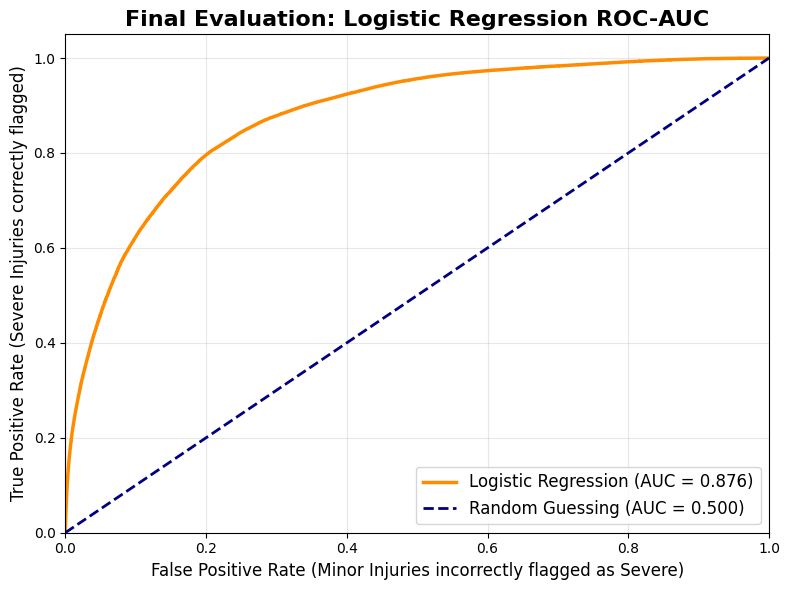

In [7]:


def plot_single_roc(model_pipeline, X_test, y_test, model_name="Final Champion Model"):
    """
    Calculates probabilities and plots the ROC-AUC curve for a single trained model 
    against the Hold-Out Test dataset.
    """
    print(f"Generating Final ROC-AUC Curve for {model_name}...")
    
    # 1. Get the probability that the patient is in the Positive Class (Hospitalized)
    # .predict_proba() returns [Probability_Released, Probability_Hospitalized]
    # We slice [:, 1] to grab only the Hospitalized probabilities.
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    
    # 2. Calculate the False Positive Rate (fpr) and True Positive Rate (tpr)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # 3. Calculate the Area Under the Curve (AUC) score
    roc_auc = auc(fpr, tpr)
    
    # 4. Set up the plotting canvas
    plt.figure(figsize=(8, 6))
    
    # 5. Plot the Model's Curve
    # We use a bold color (like dark orange) to make it pop for presentations
    plt.plot(fpr, tpr, color='darkorange', lw=2.5, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

    # 6. Plot the "Coin Flip" Baseline (Random Guessing)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Guessing (AUC = 0.500)')

    # 7. Format the Graph for Professional Presentation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Minor Injuries incorrectly flagged as Severe)', fontsize=12)
    plt.ylabel('True Positive Rate (Severe Injuries correctly flagged)', fontsize=12)
    plt.title(f'Final Evaluation: {model_name} ROC-AUC', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    # 8. Display the Graph
    plt.tight_layout()
    plt.show()

plot_single_roc(log_reg, X_eval, y_eval, model_name="Logistic Regression")

### 7. Export Model to the directory

In [8]:
print("Exporting Logistic Regression pipeline to disk...")
model_path = '../models/neiss_logistic_regression.joblib'
joblib.dump(log_reg, model_path)
print("Model successfully saved!")

Exporting Logistic Regression pipeline to disk...
Model successfully saved!
